# Interpretability: PlanckLiteMLPEmbeddingV2

El embedding MLPV2 comprime los 613 bins de espectros de potencia CMB (TT+TE+EE) a un vector de dimensión baja que condiciona el flujo normalizado (MAF) para estimación de inferencia posterior. Para entender qué información de los espectros $C_\ell$ utiliza el embedding, analizamos los pesos de la primera capa lineal (`Linear(613, 256)`). Cada fila de la matriz de pesos $W \in \mathbb{R}^{256 \times 613}$ representa los pesos de una neurona oculta, y cada columna corresponde a un bin de input. La magnitud absoluta de los pesos $\sum_j |W_{j,i}|$ a través de todas las neuronas nos indica qué bins de $\ell$ contribuyen más al embedding final, es decir, qué regiones del espectro de potencia son más informativas para inferir los parámetros cosmológicos.

In [1]:
import os
import numpy as np
import torch
import matplotlib.pyplot as plt
import scienceplots

os.chdir(os.path.join(os.getcwd(), ".."))
from cmb.simulators import PlanckLiteSimulatorR1
from zbi.utils.checkpoint import load_checkpoint
from zbi.pipeline._resolve import resolve_class

plt.style.use(["science", "notebook"])
plt.rcParams["figure.dpi"] = 150
%matplotlib inline

In [2]:
def load_embedding_from_checkpoint(ckpt_path: str) -> torch.nn.Module:
    ckpt = load_checkpoint(ckpt_path)
    emb_config = ckpt["embedding_net_config"]
    emb_class = resolve_class(emb_config["class"])
    emb_kwargs = {k: v for k, v in emb_config.items() if k != "class"}
    embedding_net = emb_class(**emb_kwargs)
    emb_state = {
        k.replace("_flow._embedding_net.1.", ""): v
        for k, v in ckpt["maf_state_dict"].items()
        if k.startswith("_flow._embedding_net.1.")
    }
    embedding_net.load_state_dict(emb_state)
    embedding_net.eval()
    return embedding_net


def plot_first_layer_analysis(
    ckpt_path: str,
    use_cl: list[str] = ["tt", "te", "ee"],
    output_path: str | None = None,
) -> None:
    embedding_net = load_embedding_from_checkpoint(ckpt_path)
    sim = PlanckLiteSimulatorR1(use_cl=use_cl)
    W1 = embedding_net.net[0].weight.data.numpy()

    n_per_cl = {cl: len(sim.bin_indices[cl]) for cl in use_cl}
    offsets = {}
    offset = 0
    for cl in use_cl:
        offsets[cl] = offset
        offset += n_per_cl[cl]

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # heatmap
    im = axes[0].imshow(W1, aspect="auto", cmap="RdBu_r", vmin=-0.15, vmax=0.15)
    for cl in use_cl[:-1]:
        axes[0].axvline(offsets[cl] + n_per_cl[cl] - 0.5, color="k", lw=0.8, ls="--")
    midpoints = [offsets[cl] + n_per_cl[cl] // 2 for cl in use_cl]
    axes[0].set_xticks(midpoints)
    axes[0].set_xticklabels([cl.upper() for cl in use_cl])
    axes[0].set_xlabel("Input bin")
    axes[0].set_ylabel("Hidden neuron")
    axes[0].set_title(f"Layer 1 weights ({W1.shape[0]} x {W1.shape[1]})")
    plt.colorbar(im, ax=axes[0], shrink=0.8)

    # importancia vs ell
    importance = np.abs(W1).sum(axis=0)
    for cl in use_cl:
        n = n_per_cl[cl]
        idx = offsets[cl]
        ell = (sim.lmin_per_bin[cl][:n] + sim.lmax_per_bin[cl][:n]) / 2
        axes[1].plot(ell, importance[idx:idx + n], ".-", label=cl.upper(), ms=3, lw=0.8)
    axes[1].set_xscale("log")
    axes[1].set_xlabel(r"$\ell$")
    axes[1].set_ylabel(r"$\sum_j |W_{j,i}|$")
    axes[1].set_title("Importancia por bin")
    axes[1].legend()

    fig.tight_layout()
    if output_path is not None:
        os.makedirs(os.path.dirname(output_path) or ".", exist_ok=True)
        fig.savefig(output_path, bbox_inches="tight")
        print(f"saved: {output_path}")
    plt.show()

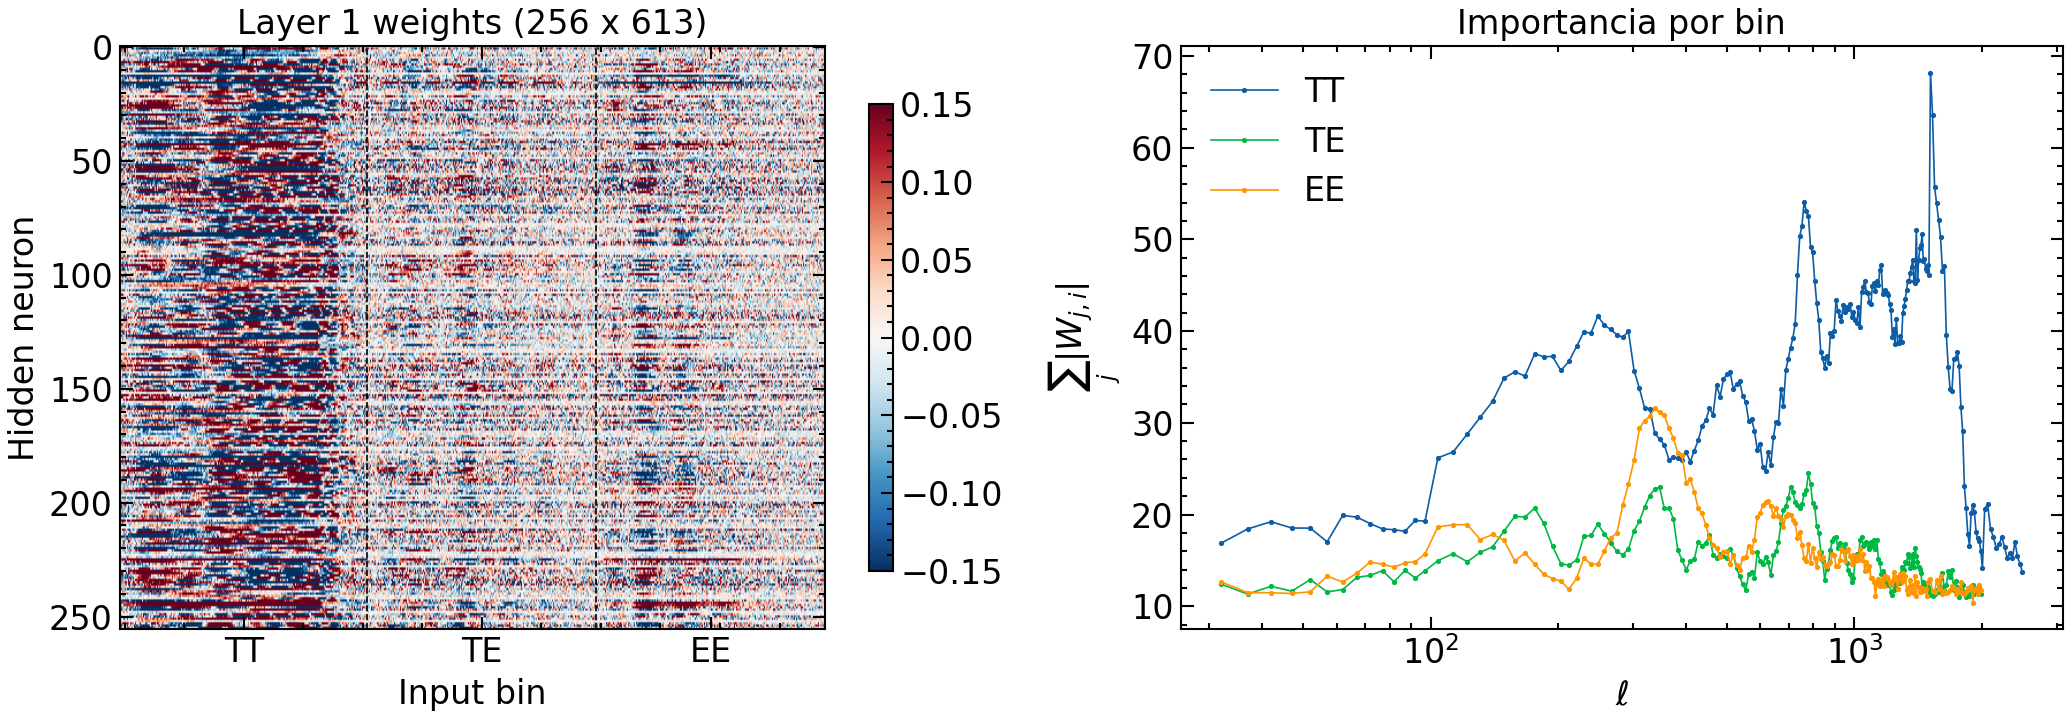

In [ ]:
plot_first_layer_analysis(
    "runs/planck_lite_r2/models/round_00000_200000_mlpv2_r1.pt",
)